In [1]:

import itertools
import matplotlib.pyplot as plt

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:

print("P = It rains, Q = Road is wet")
print("-" * 45)
print("P\tQ\tNOT P\tP -> Q")

for P, Q in itertools.product([True, False], repeat=2):
    not_P = not P
    implication = (not_P) or Q

    print(f"{P}\t{Q}\t{not_P}\t{implication}")


P = It rains, Q = Road is wet
---------------------------------------------
P	Q	NOT P	P -> Q
True	True	False	True
True	False	False	False
False	True	True	True
False	False	True	True


In [3]:

# Facts

# for all x (human(x) and mortal(x))


humans = ["Socrates"]

# Rule: All humans are mortal
def is_mortal(person):
    return person in humans

# Query
person = "Socrates"

if is_mortal(person):
    print(person, "is mortal.")
else:
    print(person, "is not known to be mortal.")


Socrates is mortal.


In [4]:

# Dataset counts
total_students = 10

passed_and_attended = 4
passed_and_absent = 2
failed_and_attended = 1
failed_and_absent = 3

# Individual event counts
passed = passed_and_attended + passed_and_absent
attended = passed_and_attended + failed_and_attended

# Individual probabilities
P_A = passed / total_students
P_B = attended / total_students

# Joint probability: passed AND attended
P_A_and_B = passed_and_attended / total_students

# Union probability: passed OR attended
P_A_or_B = P_A + P_B - P_A_and_B

print("P(A) - Probability of passing:", P_A)
print("P(B) - Probability of attendance:", P_B)
print("P(A and B) - Passed and attended:", P_A_and_B)
print("P(A or B) - Passed or attended:", P_A_or_B)


P(A) - Probability of passing: 0.6
P(B) - Probability of attendance: 0.5
P(A and B) - Passed and attended: 0.4
P(A or B) - Passed or attended: 0.7000000000000001


In [5]:

# P(A | B): Probability of passing given attendance
P_A_given_B = P_A_and_B / P_B

# P(B | A): Probability of attendance given passing
P_B_given_A = P_A_and_B / P_A

print("P(A | B) - Passed given attended:", round(P_A_given_B, 2))
print("P(B | A) - Attended given passed:", round(P_B_given_A, 2))


P(A | B) - Passed given attended: 0.8
P(B | A) - Attended given passed: 0.67


In [6]:

# Given probabilities
P_Disease = 0.01
P_Positive_given_Disease = 0.95
P_Positive_given_NoDisease = 0.05

# Probability of no disease
P_NoDisease = 1 - P_Disease

# Total probability of a positive test
P_Positive = (
    P_Positive_given_Disease * P_Disease
    + P_Positive_given_NoDisease * P_NoDisease
)

# Bayes' theorem
P_Disease_given_Positive = (
    P_Positive_given_Disease * P_Disease
) / P_Positive

print("Probability of a positive test:", round(P_Positive, 4))
print(
    "Probability of disease given positive test:",
    round(P_Disease_given_Positive, 4)
)
print(
    "Percentage:",
    round(P_Disease_given_Positive * 100, 2), "%"
)


Probability of a positive test: 0.059
Probability of disease given positive test: 0.161
Percentage: 16.1 %


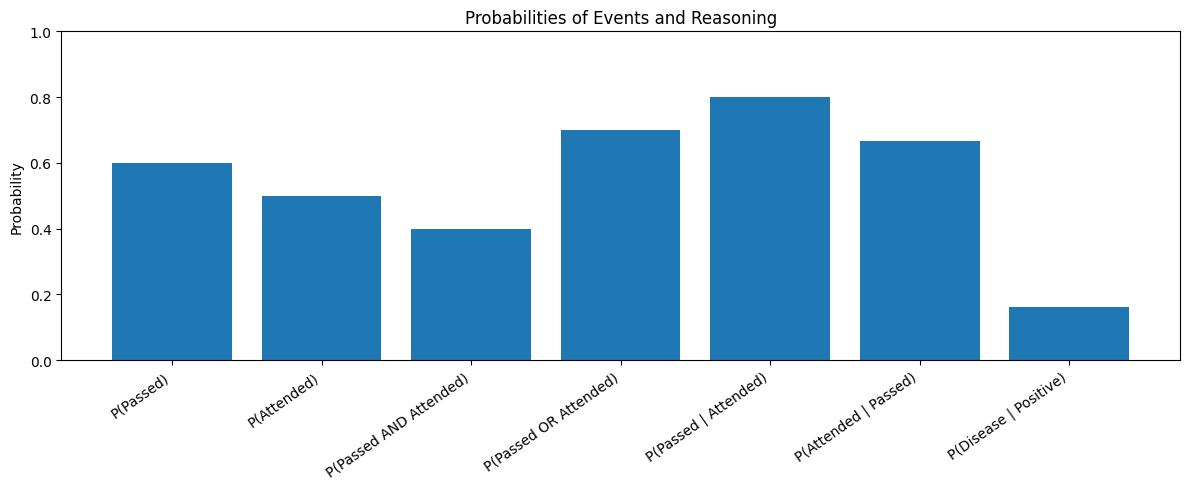

In [7]:

probability_names = [
    "P(Passed)",
    "P(Attended)",
    "P(Passed AND Attended)",
    "P(Passed OR Attended)",
    "P(Passed | Attended)",
    "P(Attended | Passed)",
    "P(Disease | Positive)"
]

probability_values = [
    P_A,
    P_B,
    P_A_and_B,
    P_A_or_B,
    P_A_given_B,
    P_B_given_A,
    P_Disease_given_Positive
]

plt.figure(figsize=(12, 5))
plt.bar(probability_names, probability_values)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Probabilities of Events and Reasoning")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


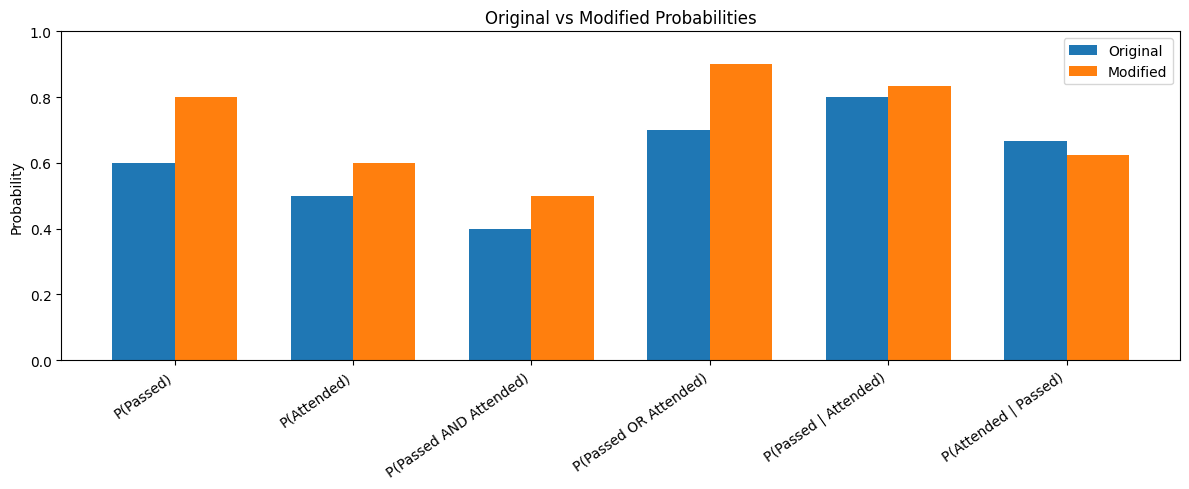

Original passing probability: 0.6
Modified passing probability: 0.8


In [8]:

# Modified dataset:
# 5 passed and attended, 3 passed and absent,
# 1 failed and attended, 1 failed and absent

modified_passed_attended = 5
modified_passed_absent = 3
modified_failed_attended = 1
modified_failed_absent = 1

modified_total = (
    modified_passed_attended
    + modified_passed_absent
    + modified_failed_attended
    + modified_failed_absent
)

modified_passed = modified_passed_attended + modified_passed_absent
modified_attended = modified_passed_attended + modified_failed_attended

modified_P_A = modified_passed / modified_total
modified_P_B = modified_attended / modified_total
modified_P_A_and_B = modified_passed_attended / modified_total
modified_P_A_or_B = modified_P_A + modified_P_B - modified_P_A_and_B
modified_P_A_given_B = modified_P_A_and_B / modified_P_B
modified_P_B_given_A = modified_P_A_and_B / modified_P_A

original_values = [
    P_A, P_B, P_A_and_B, P_A_or_B, P_A_given_B, P_B_given_A
]

modified_values = [
    modified_P_A,
    modified_P_B,
    modified_P_A_and_B,
    modified_P_A_or_B,
    modified_P_A_given_B,
    modified_P_B_given_A
]

labels = [
    "P(Passed)", "P(Attended)", "P(Passed AND Attended)",
    "P(Passed OR Attended)", "P(Passed | Attended)",
    "P(Attended | Passed)"
]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width / 2 for i in x], original_values,
        width, label="Original")
plt.bar([i + width / 2 for i in x], modified_values,
        width, label="Modified")

plt.xticks(list(x), labels, rotation=35, ha="right")
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Original vs Modified Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

print("Original passing probability:", round(P_A, 2))
print("Modified passing probability:", round(modified_P_A, 2))
